In [5]:
import numpy as np                 #for general calculations.
import matplotlib.pyplot as plt    #making plots.
import xarray as xr                #loading and working with data in an optimal way.

from matplotlib.animation import FuncAnimation  #creating animations and videos.
from IPython.display import Video, HTML         #embedding videos in the notebook

import cartopy.crs as ccrs         # to plot maps with different projections
import cartopy.feature as cfeature # to plot coastlines, land, borders, etc.
import earthaccess

#this command allows interactive plots in noteboks
%matplotlib inline   

# 1. Login
# earthaccess.login()

# 2. Search
# results = earthaccess.search_data(
#     short_name='ATL06',  # ATLAS/ICESat-2 L3A Land Ice Height
#     bounding_box=(-10, 20, 10, 50),  # Only include files in area of interest...
#     temporal=("1999-02", "2019-03"),  # ...and time period of interest.
#     count=10
# )

# # 3. Access
# files = earthaccess.download(results, "/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data")

/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
earthaccess.login()


In [7]:
results = earthaccess.search_data(
    short_name='NSIDC-0051',  # ATLAS/ICESat-2 L3A Land Ice Height
    #bounding_box=(-10, 20, 10, 50),  # Only include files in area of interest...
    temporal=("1999-02", "2019-03"),  # ...and time period of interest.
    count=10
)


In [8]:
files = earthaccess.download(results, "/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data")

QUEUEING TASKS | : 100%|██████████| 10/10 [00:00<00:00, 950.94it/s]
PROCESSING TASKS | : 100%|██████████| 10/10 [00:03<00:00,  2.98it/s]
COLLECTING RESULTS | : 100%|██████████| 10/10 [00:00<00:00, 94466.31it/s]


In [2]:
#Specify the data file to load
import xarray as xr
NSIDC_0051='/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/NSIDC0051_SEAICE_PS_N25km_19990203_v2.0.nc'    #loading from local path

seaice = xr.open_dataset(NSIDC_0051)  #xarray can open different format data, netcdf is one of them
seaice                                 #this simply prints what's in the dataset

<xarray.Dataset> Size: 1MB
Dimensions:     (time: 1, y: 448, x: 304)
Coordinates:
  * x           (x) float64 2kB -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
  * y           (y) float64 4kB 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
  * time        (time) datetime64[ns] 8B 1999-02-03
Data variables:
    crs         |S1 1B ...
    F13_ICECON  (time, y, x) float64 1MB ...
Attributes: (12/49)
    title:                     Sea Ice Concentrations from Nimbus-7 SMMR and ...
    summary:                   This data set is generated from brightness tem...
    id:                        10.5067/MPYG15WAA4WX
    license:                   Access Constraint: These data are freely, open...
    acknowledgment:            These data are produced by the NASA Cryospheri...
    metadata_link:             https://doi.org/10.5067/MPYG15WAA4WX
    ...                        ...
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east
    product_version:           v2.0
    source:                    Polar stereographic brightness temperatures fr...
    instrument:                SSM/I > Special Sensor Microwave Imager
    platform:                  DMSP 5D-2/F13 > Defense Meteorological Satelli...

<xarray.DataArray 'F13_ICECON' (y: 448, x: 304)> Size: 1MB
[136192 values with dtype=float64]
Coordinates:
  * x        (x) float64 2kB -3.838e+06 -3.812e+06 ... 3.712e+06 3.738e+06
  * y        (y) float64 4kB 5.838e+06 5.812e+06 ... -5.312e+06 -5.338e+06
    time     datetime64[ns] 8B 1999-02-03
Attributes:
    legacy_binary_header:            [ 48  48  50  53  53   0  32  32  51  48...
    units:                           Fraction between 0.0 - 1.0
    long_name:                       Sea Ice Concentration
    standard_name:                   sea_ice_area_fraction
    grid_mapping:                    crs
    coverage_content_type:           image
    valid_range:                     [  0 250]
    flag_values:                     [251 252 253 254]
    flag_meanings:                   pole_hole_mask unused coast land
    packing_convention:              netCDF
    packing_convention_description:  unpacked = scale_factor*packed + add_offset
    comment:                         The legacy_binary_header is a 300-byte s...

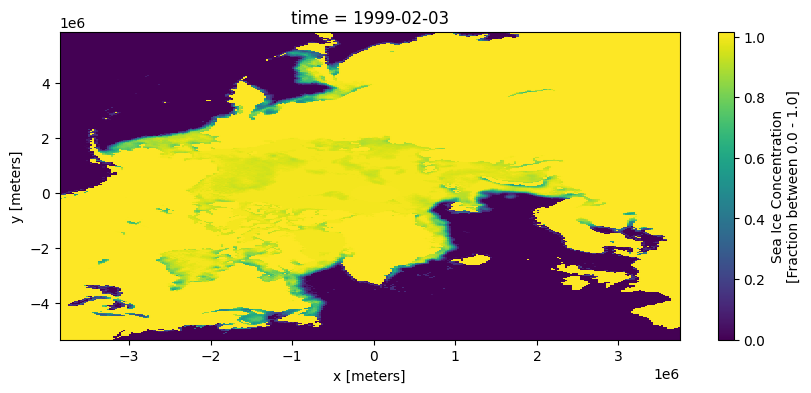

In [7]:
import matplotlib.pyplot as plt  #importing matplotlib for plotting
plt.figure(figsize=(10,4))                  #Specify figure size in inches
seaice.isel(time=-1)['F13_ICECON'].plot() #Plot using in-built xarray tools; isel() selects based on specified indices
plt.savefig('F13_ICECON.png') 
seaice.isel(time=-1)['F13_ICECON']                     #Save the figure as a png file

In [2]:
import xarray as xr
CESM2_sic = xr.open_dataset("/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r10i1p1f1_gn_185001-189912.nc")

CESM2_sic

/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.Dataset> Size: 301MB
Dimensions:    (time: 600, nj: 384, ni: 320, d2: 2, nvertices: 4)
Coordinates:
    lat        (nj, ni) float64 983kB ...
    lon        (nj, ni) float64 983kB ...
  * ni         (ni) int32 1kB 1 2 3 4 5 6 7 8 ... 314 315 316 317 318 319 320
  * nj         (nj) int32 2kB 1 2 3 4 5 6 7 8 ... 378 379 380 381 382 383 384
  * time       (time) object 5kB 1850-01-15 12:00:00 ... 1899-12-15 12:00:00
Dimensions without coordinates: d2, nvertices
Data variables:
    siconc     (time, nj, ni) float32 295MB ...
    time_bnds  (time, d2) object 10kB ...
    lat_bnds   (nj, ni, nvertices) float32 2MB ...
    lon_bnds   (nj, ni, nvertices) float32 2MB ...
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  306600.0
    case_id:                24
    ...                     ...
    sub_experiment_id:      none
    table_id:               SImon
    tracking_id:            hdl:21.14100/15041433-3ff4-4913-8b3a-15542cefd948
    variable_id:            siconc
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r10i1p1f1

In [35]:
CESM2_sic 

<xarray.Dataset> Size: 301MB
Dimensions:    (time: 600, nj: 384, ni: 320, d2: 2, nvertices: 4)
Coordinates:
    lat        (nj, ni) float64 983kB -79.22 -79.22 ... 9.969e+36 9.969e+36
    lon        (nj, ni) float64 983kB ...
  * ni         (ni) int32 1kB 1 2 3 4 5 6 7 8 ... 314 315 316 317 318 319 320
  * nj         (nj) int32 2kB 1 2 3 4 5 6 7 8 ... 378 379 380 381 382 383 384
  * time       (time) object 5kB 1850-01-15 12:00:00 ... 1899-12-15 12:00:00
Dimensions without coordinates: d2, nvertices
Data variables:
    siconc     (time, nj, ni) float32 295MB ...
    time_bnds  (time, d2) object 10kB ...
    lat_bnds   (nj, ni, nvertices) float32 2MB ...
    lon_bnds   (nj, ni, nvertices) float32 2MB ...
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  306600.0
    case_id:                24
    ...                     ...
    sub_experiment_id:      none
    table_id:               SImon
    tracking_id:            hdl:21.14100/15041433-3ff4-4913-8b3a-15542cefd948
    variable_id:            siconc
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r10i1p1f1

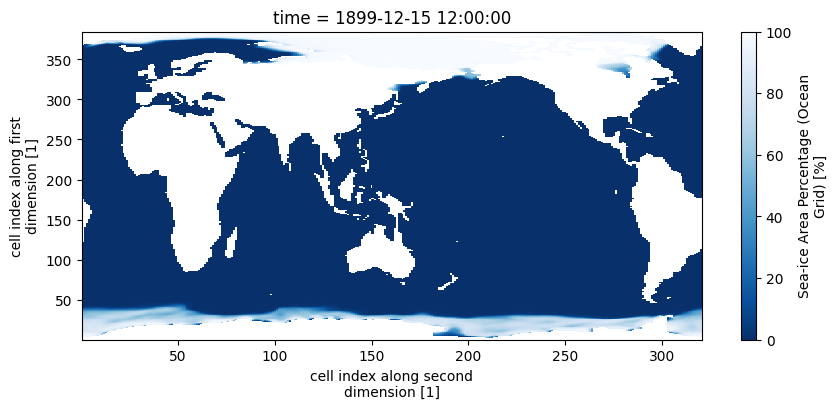

In [15]:
import matplotlib.pyplot as plt  #importing matplotlib for plotting
plt.figure(figsize=(10,4))                  #Specify figure size in inches
#Need a blue and white color map with ice as white and land as light gray
CESM2_sic.isel(time=599)['siconc'].plot(cmap = "Blues_r") #Plot using in-built xarray tools; isel() selects based on specified indices

In [25]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

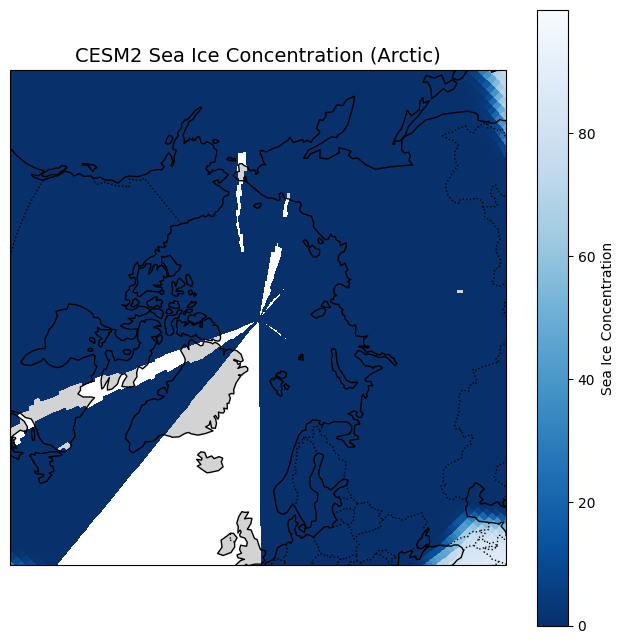

In [32]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.figure(figsize=(8, 8))

ax = plt.axes(projection=ccrs.NorthPolarStereo())  # Arctic projection
CESM2_sic.isel(time=500)['siconc'].plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Blues_r",        # ocean blue, high SIC lighter
    cbar_kwargs={"label": "Sea Ice Concentration"}
)

# Add land in light gray
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([-180, 180, 50, 90], ccrs.PlateCarree())  # focus on Arctic

plt.title("CESM2 Sea Ice Concentration (Arctic)", fontsize=14)
plt.show()


In [33]:
import matplotlib.path as mpath
theta = np.linspace(0, 2*np.pi, 100)
map_circle = mpath.Path(np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + [0.5, 0.5])

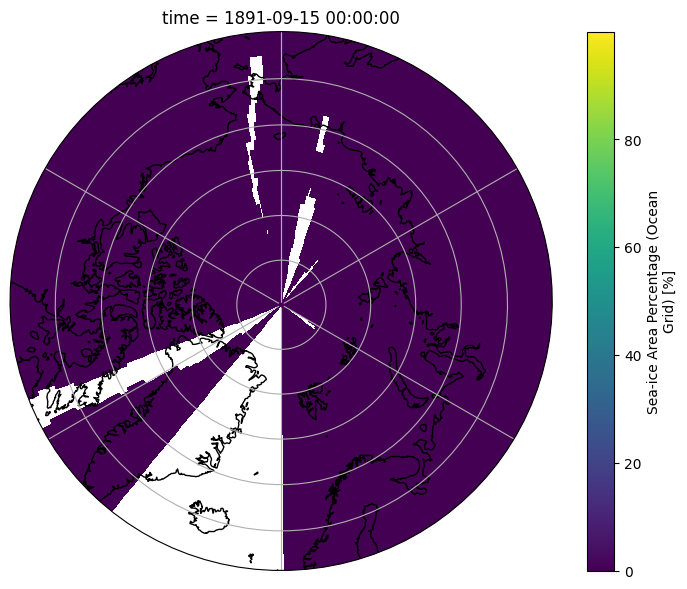

In [ ]:
fig = plt.figure(figsize=(9, 7))
ax = plt.axes(projection=ccrs.NorthPolarStereo())
ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
ax.set_boundary(map_circle, transform=ax.transAxes)
CESM2_sic.isel(time=500)['siconc'].plot(ax=ax, transform=ccrs.PlateCarree(), vmin=0, cmap='terrain')
ax.coastlines();
ax.gridlines();

Plan: I'll give you one runnable notebook code cell (JSON) that combines all NetCDF files in CESM2_Seaiceconc into a single xarray Dataset, selects the `siconc` variable, and creates/saves an mp4 animation of Arctic sea-ice concentration using the same animation pattern you showed. If ffmpeg isn't available it will fall back to saving a GIF.

Insert this single new code cell into data_imports.ipynb and run it (kernel was restarted after installs previously).

{
  "cell_type": "code",
  "metadata": {
    "language": "python"
  },
  "source": [
    "import xarray as xr",
    "from pathlib import Path",
    "import matplotlib.pyplot as plt",
    "import cartopy.crs as ccrs",
    "import cartopy.feature as cfeature",
    "from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter",
    "from IPython.display import Video, display",
    "import numpy as np",
    "",
    "# 1) Open and combine all CESM2 sea-ice files in the folder",
    "data_dir = Path('/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc')",
    "paths = sorted(data_dir.glob('*.nc'))",
    "print(f'Found {len(paths)} files: {[p.name for p in paths]}')",
    "if len(paths) == 0:",
    "    raise SystemExit('No CESM2 files found in the directory.')",
    "",
    "ds = xr.open_mfdataset([str(p) for p in paths], combine='by_coords', parallel=False)",
    "print(ds)  # quick inspection",
    "",
    "# 2) Pick the variable to animate (siconc) and prepare the data",
    "var_name = 'siconc'  # change if your variable name differs",
    "if var_name not in ds.data_vars:",
    "    raise SystemExit(f\"Variable '{var_name}' not found. Available variables: {list(ds.data_vars)}\")",
    "",
    "siconc = ds[var_name]",
    "# If siconc is 0-100, convert to fraction; here we assume 0-1 so leave as-is.",
    "",
    "# Optional: limit to Arctic (lat > 60) to speed up plotting and match earlier examples",
    "if 'lat' in siconc.dims:",
    "    siconc = siconc.sel(lat=slice(60, 90))",
    "",
    "# Optionally reduce temporal resolution for faster video (uncomment to downsample)",
    "# siconc = siconc.isel(time=slice(None, None, 1))  # keep every frame (change step as needed)",
    "",
    "n_frames = int(siconc.sizes['time'])",
    "print(f'Animating {n_frames} frames (time steps)')",
    "",
    "# 3) Animation function (follows your pattern) and save",
    "fig = plt.figure(figsize=(10, 8))",
    "",
    "def animation_func(i):",
    "    fig.clear()",
    "    ax = plt.axes(projection=ccrs.PlateCarree())",
    "    # Focus on Arctic in PlateCarree for quick coastlines; adjust extent if necessary",
    "    try:",
    "        ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())",
    "    except Exception:",
    "        pass",
    "    ax.add_feature(cfeature.LAND, color='lightgray')",
    "    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)",
    "    ax.add_feature(cfeature.BORDERS, linewidth=0.3)",
    "    ax.gridlines(draw_labels=False)",
    "",
    "    # select frame and plot without automatic colorbar, then add a colorbar",
    "    frame = siconc.isel(time=i)",
    "    # xarray returns a QuadMesh or AxesImage; keep add_colorbar=False so we can control colorbar",
    "    im = frame.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Blues_r', vmin=0, vmax=1,",
    "                    add_colorbar=False)",
    "    # add colorbar tied to last mappable",
    "    try:",
    "        plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02, label='Sea Ice Concentration')",
    "    except Exception:",
    "        # fallback: try using current image",
    "        m = plt.gci()",
    "        if m is not None:",
    "            plt.colorbar(m, ax=ax, shrink=0.6, pad=0.02, label='Sea Ice Concentration')",
    "",
    "    # title with timestamp",
    "    try:",
    "        time_label = np.datetime_as_string(frame['time'].values, unit='D')",
    "    except Exception:",
    "        time_label = str(frame['time'].values)",
    "    ax.set_title(f'Arctic {var_name} — {time_label}')",
    "    plt.axis('off')",
    "",
    "# create animation",
    "animation = FuncAnimation(fig, animation_func, frames=n_frames, blit=False)",
    "",
    "# 4) Save the animation (try ffmpeg first, fallback to GIF) and display inline",
    "out_mp4 = 'CESM2_siconc_arctic.mp4'",
    "try:",
    "    print('Saving mp4 via ffmpeg...')",
    "    writer = FFMpegWriter(fps=3, metadata=dict(artist='xarray'), bitrate=2000)",
    "    animation.save(out_mp4, writer=writer)",
    "    display(Video(out_mp4))",
    "except Exception as e:",
    "    print('FFMpeg save failed or not available, falling back to GIF. Error:', e)",
    "    out_gif = 'CESM2_siconc_arctic.gif'",
    "    try:",
    "        writer = PillowWriter(fps=3)",
    "        animation.save(out_gif, writer=writer)",
    "        display(Video(out_gif))",
    "    except Exception as e2:",
    "        print('GIF save also failed:', e2)",
    "",
    "# 5) Keep `animation` and `siconc` available for inspection",
    "animation, siconc"
  ]
}

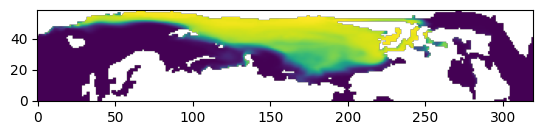

In [ ]:
for i in range(600):
    c = CESM2_sic.isel(time=i)['siconc'].values
    plt.imshow(c[325::,:]);
    plt.gca().invert_yaxis()

In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [ ]:
import xarray as xr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from IPython.display import Video, display

# --- 1) Open and combine files ---
data_dir = Path("/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc")
files = sorted(data_dir.glob("*.nc"))
if not files:
    raise SystemExit(f"No files found in {data_dir}")

ds = xr.open_mfdataset([str(p) for p in files], combine="by_coords", parallel=False)
print(ds)

# --- 2) Choose variable and subset to Arctic ---
var = "siconc"
if var not in ds.data_vars:
    raise SystemExit(f"Variable '{var}' not found. Available: {list(ds.data_vars)}")

siconc = ds[var]

# find latitude coordinate name
# lat_name = "lat"

# siconc = siconc.sel({lat_name: slice(60, 90)})

n_frames = int(siconc.sizes["time"])
print(f"Animating {n_frames} frames")

# Optional: downsample time for faster output
# siconc = siconc.isel(time=slice(None, None, 1))
# n_frames = int(siconc.sizes["time"])

# --- 3) Animation function ---
fig = plt.figure(figsize=(10, 8))

def animation_func(i):
    fig.clear()
    ax = plt.axes(projection=ccrs.PlateCarree())
    try:
        ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
    except Exception:
        pass
    ax.add_feature(cfeature.LAND, color="lightgray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.gridlines(draw_labels=False, linewidth=0.2)

    frame = siconc.isel(time=i)
    im = frame.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="Blues_r",
        vmin=0.0,
        vmax=1.0,
        add_colorbar=False,
    )
    try:
        plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02, label="Sea Ice Concentration")
    except Exception:
        m = plt.gci()
        if m is not None:
            plt.colorbar(m, ax=ax, shrink=0.6, pad=0.02, label="Sea Ice Concentration")

    # nice time label
    try:
        time_label = np.datetime_as_string(frame["time"].values, unit="D")
    except Exception:
        time_label = str(frame["time"].values)
    ax.set_title(f"Arctic {var} — {time_label}")
    plt.axis("off")

anim = FuncAnimation(fig, animation_func, frames=n_frames, blit=False)

# --- 4) Save (ffmpeg then GIF fallback) ---
out_mp4 = "CESM2_siconc_arctic.mp4"
try:
    print("Saving mp4 via ffmpeg...")
    writer = FFMpegWriter(fps=3, metadata=dict(artist="xarray"), bitrate=2000)
    anim.save(out_mp4, writer=writer)
    display(Video(out_mp4))
except Exception as e:
    print("ffmpeg save failed, falling back to GIF:", e)
    out_gif = "CESM2_siconc_arctic.gif"
    try:
        writer = PillowWriter(fps=3)
        anim.save(out_gif, writer=writer)
        display(Video(out_gif))
    except Exception as e2:
        print("GIF save failed:", e2)

# keep references for interactive use
anim, siconc

/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: vari

<xarray.Dataset> Size: 9GB
Dimensions:    (time: 1980, nj: 384, ni: 320, d2: 2, nvertices: 4)
Coordinates:
    lat        (nj, ni) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    lon        (nj, ni) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
  * ni         (ni) int32 1kB 1 2 3 4 5 6 7 8 ... 314 315 316 317 318 319 320
  * nj         (nj) int32 2kB 1 2 3 4 5 6 7 8 ... 378 379 380 381 382 383 384
  * time       (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
Dimensions without coordinates: d2, nvertices
Data variables:
    siconc     (time, nj, ni) float32 973MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    time_bnds  (time, d2) object 32kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (time, nj, ni, nvertices) float32 4GB dask.array<chunksize=(600, 384, 320, 4), meta=np.ndarray>
    lon_bnds   (time, nj, ni, nvertices) float32 4GB dask.array<chunksize=(600, 384, 320, 4), meta=np.ndarray>
Attributes: (12/45

/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


ffmpeg save failed, falling back to GIF: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1000x800', '-pix_fmt', 'rgba', '-framerate', '3', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-b', '2000k', '-metadata', 'artist=xarray', '-y', 'CESM2_siconc_arctic.mp4']' returned non-zero exit status 255.


In [6]:

import xarray as xr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from IPython.display import Video, display
data_dir = Path("/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc")
files = sorted(data_dir.glob("*.nc"))
if not files:
    raise SystemExit(f"No files found in {data_dir}")

ds = xr.open_mfdataset([str(p) for p in files], combine="by_coords", parallel=False)
ds

/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: vari

<xarray.Dataset> Size: 9GB
Dimensions:    (time: 1980, nj: 384, ni: 320, d2: 2, nvertices: 4)
Coordinates:
    lat        (nj, ni) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    lon        (nj, ni) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
  * ni         (ni) int32 1kB 1 2 3 4 5 6 7 8 ... 314 315 316 317 318 319 320
  * nj         (nj) int32 2kB 1 2 3 4 5 6 7 8 ... 378 379 380 381 382 383 384
  * time       (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
Dimensions without coordinates: d2, nvertices
Data variables:
    siconc     (time, nj, ni) float32 973MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    time_bnds  (time, d2) object 32kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (time, nj, ni, nvertices) float32 4GB dask.array<chunksize=(600, 384, 320, 4), meta=np.ndarray>
    lon_bnds   (time, nj, ni, nvertices) float32 4GB dask.array<chunksize=(600, 384, 320, 4), meta=np.ndarray>
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  306600.0
    case_id:                24
    ...                     ...
    sub_experiment_id:      none
    table_id:               SImon
    tracking_id:            hdl:21.14100/15041433-3ff4-4913-8b3a-15542cefd948
    variable_id:            siconc
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r10i1p1f1

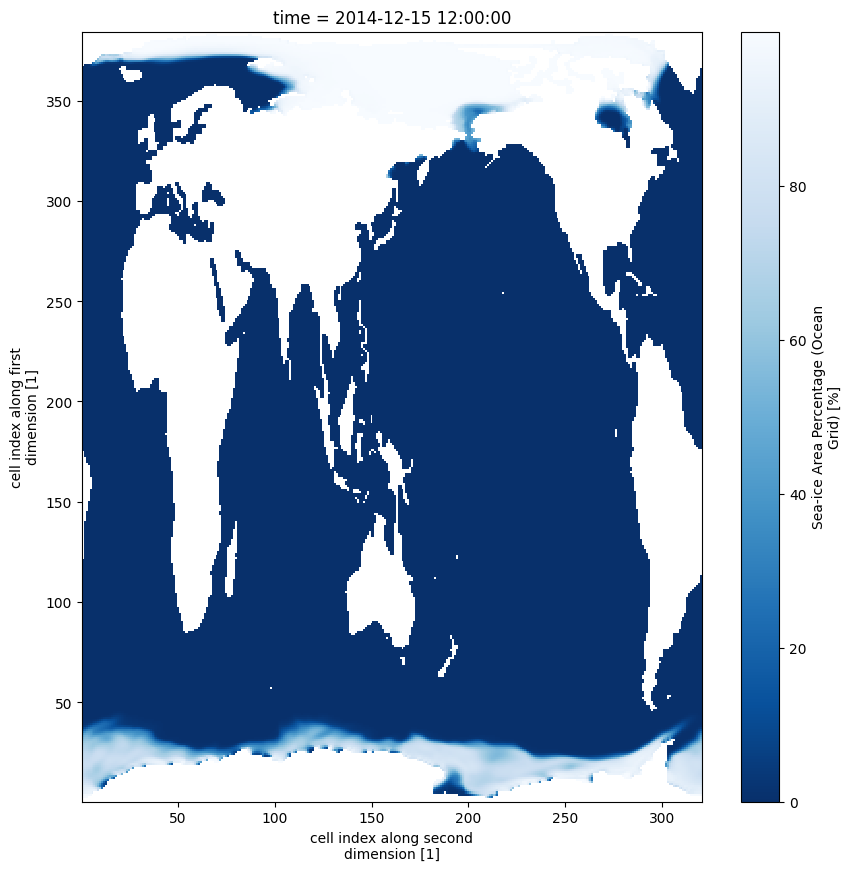

In [9]:
plt.figure(figsize=(10, 10))
ds.isel(time=1979)['siconc'].plot(cmap = "Blues_r") 

In [7]:
SIC=ds['siconc'].values[:,320::,:]/100


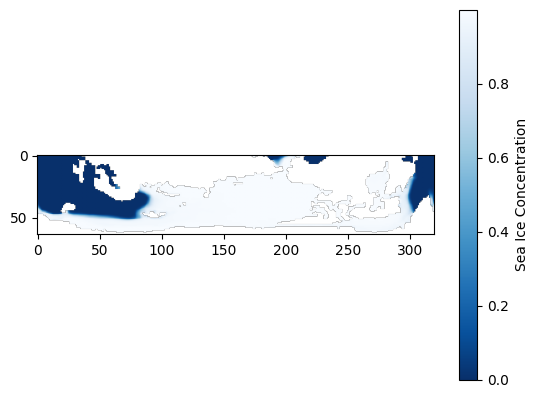

In [8]:
plt.imshow(SIC[0,:,:], cmap='Blues_r')
plt.colorbar(label='Sea Ice Concentration')

In [ ]:
N_samples=np.shape(SIC)[0]-1

X=np.zeros((np.shape(SIC)[1],np.shape(SIC)[2],3,N_samples))

Y=np.zeros((np.shape(SIC)[1],np.shape(SIC)[2],1,N_samples))

for i in range(N_samples):
    t0=np.random.randint(0, np.shape(SIC)[0]-1)
    X[:,:,0,i]=SIC[t0,:,:]
    X[:, :, 1, i] = SIC[t0 - 1, :, :]
    X[:, :, 2, i] = SIC[t0 - 2, :, :]
    Y[:,:,0,i]=SIC[t0+1,:,:]


In [4]:
np.shape(Y)

NameError: name 'np' is not defined

In [51]:
Y_pred_persistence=X;

MSE=np.nanmean((Y_pred_persistence-Y)**2)

In [54]:
np.sqrt(MSE)

np.float64(0.16846560141154077)

In [46]:
X

array([[[[ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        ...,

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.]]],


       [[[ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        ...,

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.]]],


       [[[ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        ...,

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.]]],


       ...,


       [[[nan, nan, nan, ..., nan, nan, nan]],

        [[nan, nan, nan, .

In [12]:
var = "siconc"
if var not in ds.data_vars:
    raise SystemExit(f"Variable '{var}' not found. Available: {list(ds.data_vars)}")

siconc = ds[var]

# find latitude coordinate name
# lat_name = "lat"

# siconc = siconc.sel({lat_name: slice(60, 90)})

n_frames = int(siconc.sizes["time"])
print(f"Animating {n_frames} frames")

Animating 1980 frames


In [ ]:
fig = plt.figure(figsize=(10, 8))

def animation_func(i):
    fig.clear()
    ax = plt.axes(projection=ccrs.PlateCarree())
    try:
        ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
    except Exception:
        pass
    ax.add_feature(cfeature.LAND, color="lightgray")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.gridlines(draw_labels=False, linewidth=0.2)

    frame = siconc.isel(time=i)
    im = frame.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="Blues_r",
        vmin=0.0,
        vmax=1.0,
        add_colorbar=False,
    )
    try:
        plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02, label="Sea Ice Concentration")
    except Exception:
        m = plt.gci()
        if m is not None:
            plt.colorbar(m, ax=ax, shrink=0.6, pad=0.02, label="Sea Ice Concentration")

    # nice time label
    try:
        time_label = np.datetime_as_string(frame["time"].values, unit="D")
    except Exception:
        time_label = str(frame["time"].values)
    ax.set_title(f"Arctic {var} — {time_label}")
    plt.axis("off")

anim = FuncAnimation(fig, animation_func, frames=1980, blit=False)

# --- 4) Save (ffmpeg then GIF fallback) ---
out_mp4 = "CESM2_siconc_arctic.mp4"
try:
    print("Saving mp4 via ffmpeg...")
    writer = FFMpegWriter(fps=3, metadata=dict(artist="xarray"), bitrate=2000)
    anim.save(out_mp4, writer=writer)
    display(Video(out_mp4))
except Exception as e:
    print("ffmpeg save failed, falling back to GIF:", e)
    out_gif = "CESM2_siconc_arctic.gif"
    try:
        writer = PillowWriter(fps=3)
        anim.save(out_gif, writer=writer)
        display(Video(out_gif))
    except Exception as e2:
        print("GIF save failed:", e2)

# keep references for interactive use
anim, siconc

Saving mp4 via ffmpeg...
ffmpeg save failed, falling back to GIF: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1000x800', '-pix_fmt', 'rgba', '-framerate', '3', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-b', '2000k', '-metadata', 'artist=xarray', '-y', 'CESM2_siconc_arctic.mp4']' returned non-zero exit status 255.


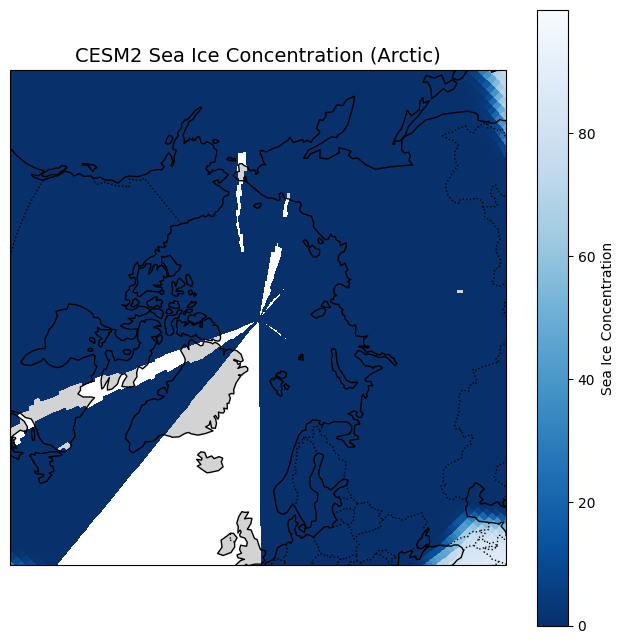

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.figure(figsize=(8, 8))

ax = plt.axes(projection=ccrs.NorthPolarStereo())  # Arctic projection
ds.isel(time=500)['siconc'].plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Blues_r",        # ocean blue, high SIC lighter
    cbar_kwargs={"label": "Sea Ice Concentration"}
)

# Add land in light gray
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_extent([-180, 180, 50, 90], ccrs.PlateCarree())  # focus on Arctic

plt.title("CESM2 Sea Ice Concentration (Arctic)", fontsize=14)
plt.show()


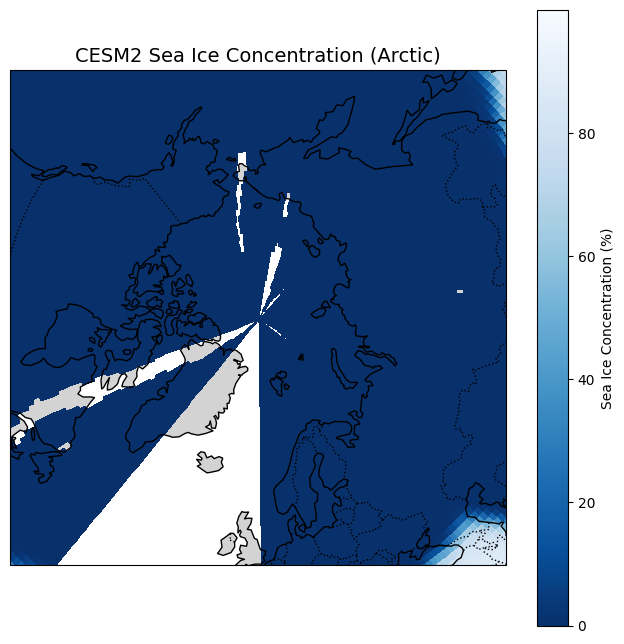

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select one time step
sic = ds['siconc'].isel(time=500)

plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

sic.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),   # because lat/lon are geographic
    cmap="Blues_r",
    cbar_kwargs={"label": "Sea Ice Concentration (%)"}
)

# Add land and coastlines
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Focus on the Arctic
ax.set_extent([-180, 180, 50, 90], ccrs.PlateCarree())

plt.title("CESM2 Sea Ice Concentration (Arctic)", fontsize=14)
plt.show()


In [11]:
print(ds['siconc'].isel(time=500).shape)

(384, 320)


In [12]:
print(ds['lon'].shape, ds['lat'].shape)

(384, 320) (384, 320)


In [15]:
print(ds['siconc'])
print(ds['siconc'].dims)
print(ds['siconc'].shape)

<xarray.DataArray 'siconc' (time: 1980, nj: 384, ni: 320)> Size: 973MB
dask.array<concatenate, shape=(1980, 384, 320), dtype=float32, chunksize=(1, 384, 320), chunktype=numpy.ndarray>
Coordinates:
    lat      (nj, ni) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    lon      (nj, ni) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
  * ni       (ni) int32 1kB 1 2 3 4 5 6 7 8 ... 313 314 315 316 317 318 319 320
  * nj       (nj) int32 2kB 1 2 3 4 5 6 7 8 ... 377 378 379 380 381 382 383 384
  * time     (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
Attributes: (12/19)
    cell_measures:  area: areacello
    cell_methods:   area: mean where sea time: mean
    comment:        Area fraction of grid cell covered by sea ice
    description:    Area fraction of grid cell covered by sea ice
    frequency:      mon
    id:             siconc
    ...             ...
    time_label:     time-mean
    time_title:     Temporal mean
    title:      

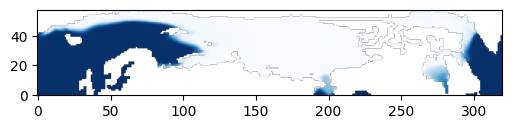

In [20]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

sic = ds['siconc'].values  # shape (time, nj, ni)

fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(sic[0, 325:, :], cmap="Blues_r", origin="upper", animated=True)
#reverse y-axis
plt.gca().invert_yaxis()

def update(i):
    im.set_array(sic[i, 325:, :])
    return [im]

ani = animation.FuncAnimation(fig, update, frames=600, interval=100, blit=True)

# Save as MP4 (needs ffmpeg installed)
ani.save("seaice.mp4", fps=10, dpi=150)

# Or view inline in Jupyter:
# from IPython.display import HTML
# HTML(ani.to_jshtml())


Using dataset: /Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r10i1p1f1_gn_190001-194912.nc
Test dataset size (approx): 119


/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Test L1 (mean abs error) from Trainer.evaluate: 0.0195
Prediction: [[[       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  [0.9892215  0.9869126  0.98692113 ...        nan        nan        nan]
  ...
  [       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]]

 [[       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  [0.99611837 0.99521124 0.99562526 ...        nan        nan        nan]
  ...
  [       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]]

 [[       nan        nan     

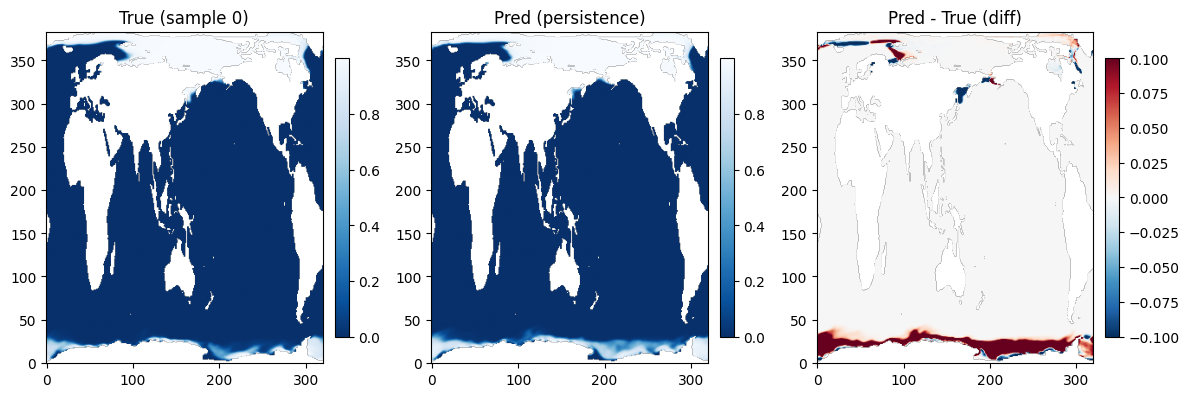

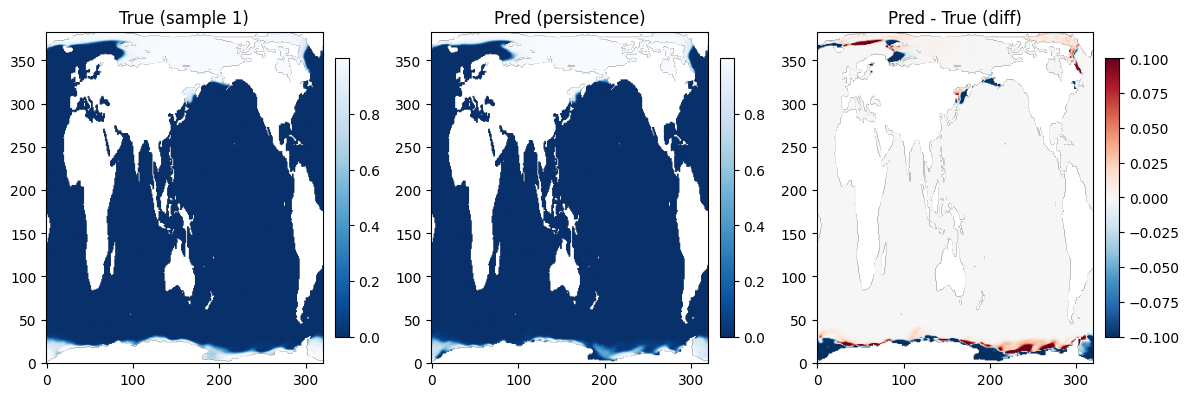

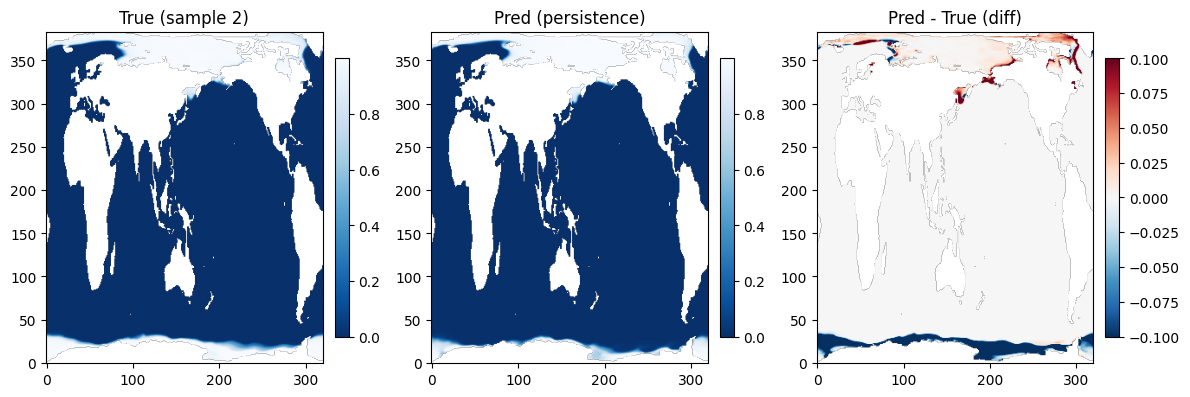

In [4]:
# Persistence smoke test (paste into notebook cell)
import os
import sys
import glob
import numpy as np
import matplotlib.pyplot as plt

# Make repo importable if not already (adjust if needed)
if 'models' not in sys.modules:
    repo_root = os.path.dirname(os.getcwd()) # assuming this script is in a subdirectory
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)

from models.data import get_dataloaders
from models.models import PersistenceModel
from models.train import Trainer
from models.utils import mae, rmse

# 1) Find a dataset under data/ (prefer .zarr, then .nc)
data_root = os.path.join(os.path.dirname(os.getcwd()), "data")  # Go up one level to repo root, then into data/
ds_path = "/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r10i1p1f1_gn_190001-194912.nc"
# zarrs = glob.glob(os.path.join(data_root, "**", "*.zarr"), recursive=True)
# if zarrs:
#     ds_path = zarrs[0]
# else:
#     ncs = glob.glob(os.path.join(data_root, "**", "*.nc"), recursive=True)
#     if ncs:
#         ds_path = ncs[0]
# if ds_path is None:
#     raise RuntimeError(f"No .zarr or .nc datasets found under {data_root}/. Please add one containing variable 'siconc'.")

print("Using dataset:", ds_path)

# 2) Build chronologically-split dataloaders (train earliest, test latest)
input_vars = ["siconc"]
target_var = "siconc"
train_loader, test_loader = get_dataloaders(ds_path, input_vars, target_var,
                                            lead=1, batch_size=8, test_fraction=0.2,
                                            num_workers=0, time_split=True)

# Quick sanity
n_test_samples = 0
try:
    # If DataLoader wraps Subset, dataset attribute exists; else this is best-effort
    n_test_samples = len(test_loader.dataset)
except Exception:
    pass
print("Test dataset size (approx):", n_test_samples)

# 3) Persistence baseline + evaluate
model = PersistenceModel()      # predicts current input channel as future
trainer = Trainer(model)

# Evaluate (L1) via trainer.evaluate
test_loss = trainer.evaluate(test_loader)   # same as MAE because L1Loss
print(f"Test L1 (mean abs error) from Trainer.evaluate: {test_loss:.4f}")

# 4) Get predictions & truths as numpy arrays for further metrics & plots
preds, trues, times = trainer.predict_batch(test_loader, max_batches=10)
print("Prediction:", preds)
print("Truth:", trues)
print("Train Loader:", train_loader)
# preds/trues shapes: (N, H, W) because predict_batch squeezes single-channel outputs

# Compute aggregated metrics
print("MAE (numpy):", mae(preds, trues))
print("RMSE (numpy):", rmse(preds, trues))

# 5) Plot first few examples: true / pred / diff
n_show = min(3, preds.shape[0])
for i in range(n_show):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    vmin = np.nanmin([trues[i], preds[i]])
    vmax = np.nanmax([trues[i], preds[i]])

    im0 = axes[0].imshow(trues[i], origin='lower', vmin=vmin, vmax=vmax, cmap='Blues_r')
    axes[0].set_title(f"True (sample {i})")
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(preds[i], origin='lower', vmin=vmin, vmax=vmax, cmap='Blues_r')
    axes[1].set_title(f"Pred (persistence)")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    diff = preds[i] - trues[i]
    im2 = axes[2].imshow(diff, origin='lower', cmap='RdBu_r', vmin=-np.max(np.abs(diff)), vmax=np.max(np.abs(diff)))
    axes[2].set_title("Pred - True (diff)")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

In [3]:
import os
import sys

# Debug current state
print("Current working directory:", os.getcwd())
print("Python path:", sys.path[:3])  # First few entries
print("Contents of current directory:", os.listdir('.'))

# Check if models folder exists and is accessible
models_path = os.path.join(os.getcwd(), 'models')
print(f"Models path: {models_path}")
print(f"Models folder exists: {os.path.exists(models_path)}")

if os.path.exists(models_path):
    print(f"Models folder contents: {os.listdir(models_path)}")

Current working directory: /Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/notebooks
Python path: ['/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/notebooks', '/Library/Frameworks/Python.framework/Versions/3.11/lib/python311.zip', '/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11']
Contents of current directory: ['seaice.mp4', 'F13_ICECON.png', 'data_imports.ipynb']
Models path: /Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/notebooks/models
Models folder exists: False


Using repo root: /Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice
Using dataset: /Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r10i1p1f1_gn_190001-194912.nc


/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Sample batch shapes xb=torch.Size([8, 2, 384, 320]), yb=torch.Size([8, 1, 384, 320]), inferred in_ch=2


Train ep 1/1: 100%|██████████| 60/60 [01:50<00:00,  1.84s/it]


Epoch 1 train loss: 0.0568
Epoch 1 test loss: 0.0289
History: {'train_loss': [0.0568362337226669], 'test_loss': [0.02892143608016126], 'val_loss': []}
Test L1 loss: 0.02892143608016126
Preds shape: (40, 384, 320) Trues shape: (40, 384, 320)
MAE: 0.02885914221405983 RMSE: 0.08993962407112122


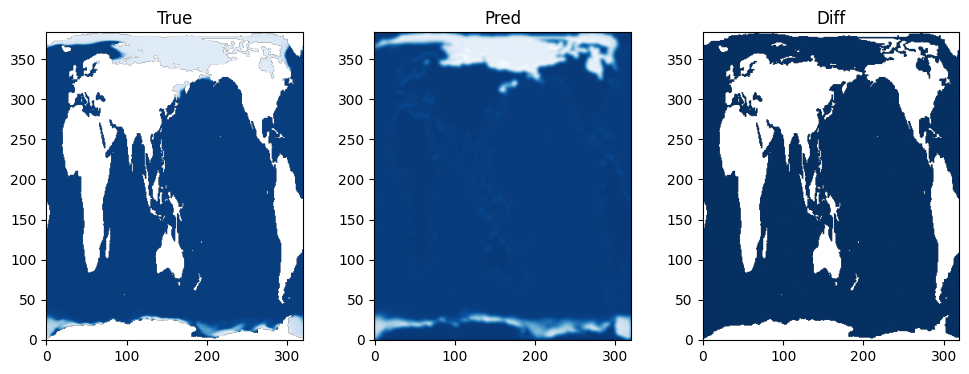

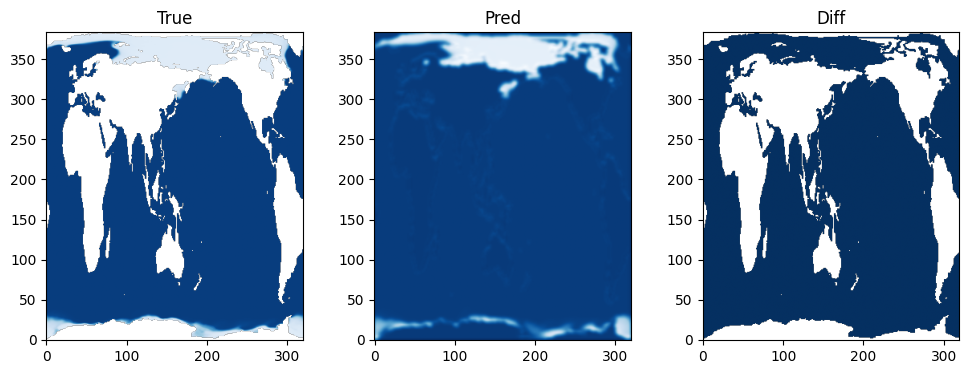

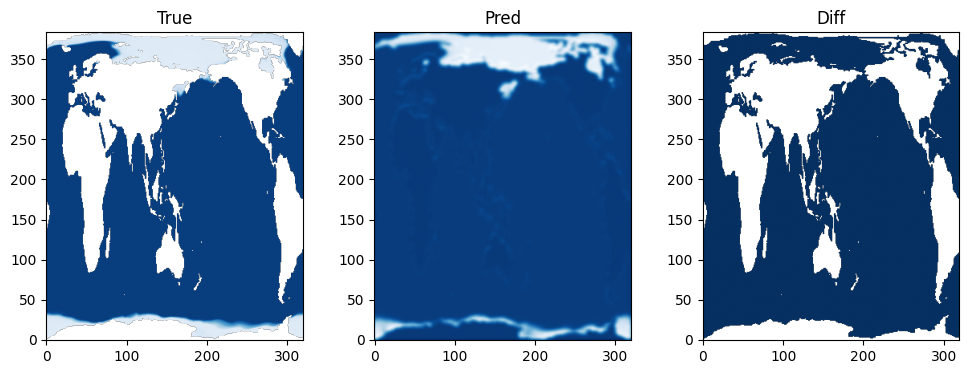

In [3]:
from pathlib import Path
import sys
epochs = 1

# Find repository root (folder containing models) and add to sys.path
p = Path.cwd()
repo_root = None
for i in range(6):
   if (p / 'models').is_dir():
       repo_root = p
       break
   if p.parent == p:
       break
   p = p.parent
if repo_root is None:
   repo_root = Path.cwd()
sys.path.insert(0, str(repo_root))
print('Using repo root:', repo_root)

# Import and run the quick CNN test (adjust path below if needed)

from models.test_cnn import run_quick_test
from models.utils import plot_epoch_comparison, get_arctic_row_slice, overlay_mask_image

ds_path = '/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r10i1p1f1_gn_190001-194912.nc'

# Run a short smoke-test (small epochs) to exercise the pipeline
run_quick_test(ds_path, batch_size=8, epochs=epochs)

# Alternative: execute the script directly in the notebook (uncomment if desired)
# %run -i models/test_cnn.py

In [1]:
import xarray as xr
import glob

# List all .nc files (adjust path as needed)
nc_files = glob.glob("/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/*.nc")

# Concatenate along time dimension
ds = xr.open_mfdataset([str(p) for p in nc_files], combine="nested", parallel=False, compat="override")

# # Save to new .nc file
# ds.to_netcdf("combined_seaice.nc")
# Find type of ds

/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: vari

In [ ]:
nc_files = glob.glob("/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/*.nc")

# Concatenate along time dimension
ds = xr.open_mfdataset([str(p) for p in nc_files], combine="nested", parallel=False, compat="override")


N_samples=np.shape(SIC)[0]-1

X=np.zeros((np.shape(SIC)[1],np.shape(SIC)[2],3,N_samples))

Y=np.zeros((np.shape(SIC)[1],np.shape(SIC)[2],1,N_samples))

for i in range(N_samples):
    t0=np.random.randint(0, np.shape(SIC)[0]-1)
    X[:,:,0,i]=SIC[t0,:,:]
    X[:, :, 1, i] = SIC[t0 - 1, :, :]
    X[:, :, 2, i] = SIC[t0 - 2, :, :]
    Y[:,:,0,i]=SIC[t0+1,:,:]


In [3]:
nc_files = glob.glob("/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/*.nc")
nc_files

NameError: name 'glob' is not defined

In [2]:
ds

<xarray.Dataset> Size: 979MB
Dimensions:    (ni: 320, nj: 384, time: 1980, d2: 2, nvertices: 4)
Coordinates:
  * ni         (ni) int32 1kB 1 2 3 4 5 6 7 8 ... 314 315 316 317 318 319 320
  * nj         (nj) int32 2kB 1 2 3 4 5 6 7 8 ... 378 379 380 381 382 383 384
  * time       (time) object 16kB 1850-01-15 12:00:00 ... 2014-12-15 12:00:00
    lat        (nj, ni) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    lon        (nj, ni) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
Dimensions without coordinates: d2, nvertices
Data variables:
    siconc     (time, nj, ni) float32 973MB dask.array<chunksize=(1, 384, 320), meta=np.ndarray>
    time_bnds  (time, d2) object 32kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bnds   (nj, ni, nvertices) float32 2MB dask.array<chunksize=(384, 320, 4), meta=np.ndarray>
    lon_bnds   (nj, ni, nvertices) float32 2MB dask.array<chunksize=(384, 320, 4), meta=np.ndarray>
Attributes: (12/45)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   674885.0
    branch_time_in_parent:  306600.0
    case_id:                24
    ...                     ...
    sub_experiment_id:      none
    table_id:               SImon
    tracking_id:            hdl:21.14100/15041433-3ff4-4913-8b3a-15542cefd948
    variable_id:            siconc
    variant_info:           CMIP6 20th century experiments (1850-2014) with C...
    variant_label:          r10i1p1f1

In [ ]:
from pathlib import Path
import sys
epochs = 1

# Find repository root (folder containing models) and add to sys.path
p = Path.cwd()
repo_root = None
for i in range(6):
   if (p / 'models').is_dir():
       repo_root = p
       break
   if p.parent == p:
       break
   p = p.parent
if repo_root is None:
   repo_root = Path.cwd()
sys.path.insert(0, str(repo_root))
print('Using repo root:', repo_root)

from models.U_net import run_robust_test

# Exact same interface as your existing function
ds_path = "/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc"
model, history = run_robust_test(ds_path, batch_size=8, epochs=epochs)

Using repo root: /Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice
=== Multi-Variable U-Net Test ===
Input variables: ['siconc']
Target variable: siconc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r10i1p1f1_gn_190001-194912.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r11i1p1f1_gn_200001-201412.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r9i1p1f1_gn_195001-199912.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r10i1p1f1_gn_185001-189912.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r7i1p1f1_gn_200001-201412.nc


/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: vari

/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r10i1p1f1_gn_195001-199912.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r9i1p1f1_gn_185001-189912.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r9i1p1f1_gn_190001-194912.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r8i1p1f1_gn_200001-201412.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r9i1p1f1_gn_200001-201412.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r8i1p1f1_gn_190001-194912.nc


/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'siconc' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/.venv/lib/python3.11/site-packages/xarray/conventions.py:204: SerializationWarning: vari

/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r7i1p1f1_gn_185001-189912.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r7i1p1f1_gn_190001-194912.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r8i1p1f1_gn_185001-189912.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r11i1p1f1_gn_195001-199912.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r11i1p1f1_gn_185001-189912.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r8i1p1f1_gn_195001-199912.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r10i1p1f1_gn_200001-201412.nc
/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_histo

In [ ]:
# Simple test with just sea ice concentration
from pathlib import Path
import sys
epochs = 1

# Find repository root (folder containing models) and add to sys.path
p = Path.cwd()
repo_root = None
for i in range(6):
   if (p / 'models').is_dir():
       repo_root = p
       break
   if p.parent == p:
       break
   p = p.parent
if repo_root is None:
   repo_root = Path.cwd()
sys.path.insert(0, str(repo_root))
print('Using repo root:', repo_root)

from models.Swin_transformer import run_swin_test

# Exact same interface as your existing function
ds_path = "/Users/amanjhurani/LocalData_SeaIce/DSO_Sea_Ice/data/CESM2_Seaiceconc/siconc_SImon_CESM2_historical_r10i1p1f1_gn_185001-189912.nc"

model, history = run_swin_test(
    ds_path=ds_path,
    variables=['siconc'], 
    batch_size=8,
    epochs=1,
    img_size=384  # Start with fewer epochs for testing
)